In [1]:
import pandas as pd
import numpy as np
import xgboost
print("All good!")

All good!


In [2]:
df = pd.read_csv(
    '../data/raw/variant_summary.txt',
    sep='\t',
    low_memory=False
)
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (8990435, 43)


In [3]:
df.head()

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
1,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
2,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
3,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
4,15043,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),9640,ZNF592,HGNC:28986,Uncertain significance,0,"Jun 29, 2015",150829393,...,A,-,-,-,-,-,-,SCV000020157,-,-


In [4]:
df.columns.tolist()

['#AlleleID',
 'Type',
 'Name',
 'GeneID',
 'GeneSymbol',
 'HGNC_ID',
 'ClinicalSignificance',
 'ClinSigSimple',
 'LastEvaluated',
 'RS# (dbSNP)',
 'nsv/esv (dbVar)',
 'RCVaccession',
 'PhenotypeIDS',
 'PhenotypeList',
 'Origin',
 'OriginSimple',
 'Assembly',
 'ChromosomeAccession',
 'Chromosome',
 'Start',
 'Stop',
 'ReferenceAllele',
 'AlternateAllele',
 'Cytogenetic',
 'ReviewStatus',
 'NumberSubmitters',
 'Guidelines',
 'TestedInGTR',
 'OtherIDs',
 'SubmitterCategories',
 'VariationID',
 'PositionVCF',
 'ReferenceAlleleVCF',
 'AlternateAlleleVCF',
 'SomaticClinicalImpact',
 'SomaticClinicalImpactLastEvaluated',
 'ReviewStatusClinicalImpact',
 'Oncogenicity',
 'OncogenicityLastEvaluated',
 'ReviewStatusOncogenicity',
 'SCVsForAggregateGermlineClassification',
 'SCVsForAggregateSomaticClinicalImpact',
 'SCVsForAggregateOncogenicityClassification']

In [5]:
df['ClinicalSignificance'].value_counts()

ClinicalSignificance
Uncertain significance                                  4677442
Likely benign                                           2183233
-                                                        490956
Benign                                                   425331
Pathogenic                                               405175
                                                         ...   
Benign; Affects; association; other                           2
Pathogenic/Likely pathogenic/Established risk allele          2
Uncertain significance; Affects                               2
confers sensitivity; other                                    2
Established risk allele; association                          2
Name: count, Length: 106, dtype: int64

In [6]:
df_filtered = df[df['ClinicalSignificance'].isin(['Pathogenic', 'Benign'])]
print("Filtered shape:", df_filtered.shape)

Filtered shape: (830506, 43)


In [7]:
df_filtered = df_filtered.copy()
df_filtered['label'] = df_filtered['ClinicalSignificance'].map({
    'Benign': 0,
    'Pathogenic': 1
})
print(df_filtered['label'].value_counts())

label
0    425331
1    405175
Name: count, dtype: int64


In [8]:
cols = ['Type', 'GeneSymbol', 'Chromosome', 'Start', 'Stop', 
        'ReferenceAllele', 'AlternateAllele', 'label']
df_clean = df_filtered[cols]
print(df_clean.shape)
df_clean.head()

(830506, 8)


,Type,GeneSymbol,Chromosome,Start,Stop,ReferenceAllele,AlternateAllele,label
2,Deletion,AP5Z1,7,4827361,4827374,na,na,1
3,Deletion,AP5Z1,7,4787730,4787743,na,na,1
6,single nucleotide variant,FOXRED1,11,126145284,126145284,na,na,1
7,single nucleotide variant,FOXRED1,11,126275389,126275389,na,na,1
22,single nucleotide variant,HFE,6,26093236,26093236,na,na,0


In [9]:
df_clean.isnull().sum()

Type               0
GeneSymbol         0
Chromosome         0
Start              0
Stop               0
ReferenceAllele    0
AlternateAllele    0
label              0
dtype: int64

In [10]:
df_clean = df_clean.dropna()
print("Shape after dropping nulls:", df_clean.shape)

Shape after dropping nulls: (830506, 8)


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean = df_clean.copy()
df_clean['Type_encoded'] = le.fit_transform(df_clean['Type'])
print(df_clean['Type_encoded'].value_counts())

Type_encoded
13    530110
1     160573
2      69069
6      24965
10     14268
4      12371
3       8989
9       8980
8        728
5        237
7        110
12        68
0         36
11         2
Name: count, dtype: int64


In [12]:
X = df_clean[['Type_encoded', 'Start', 'Stop']]
y = df_clean['label']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("\nLabel distribution:")
print(y.value_counts())

Features shape: (830506, 3)
Labels shape: (830506,)

Label distribution:
label
0    425331
1    405175
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 664404
Testing samples: 166102


In [14]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [15]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("AUC-ROC Score:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

AUC-ROC Score: 0.7892385160093203

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.76     85067
           1       0.79      0.61      0.69     81035

    accuracy                           0.73    166102
   macro avg       0.74      0.73      0.73    166102
weighted avg       0.74      0.73      0.73    166102



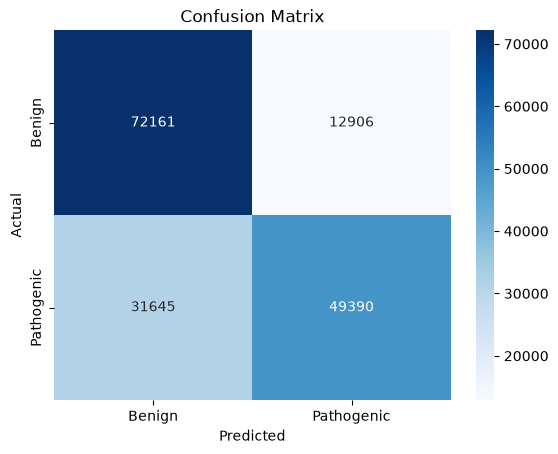

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Pathogenic'],
            yticklabels=['Benign', 'Pathogenic'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

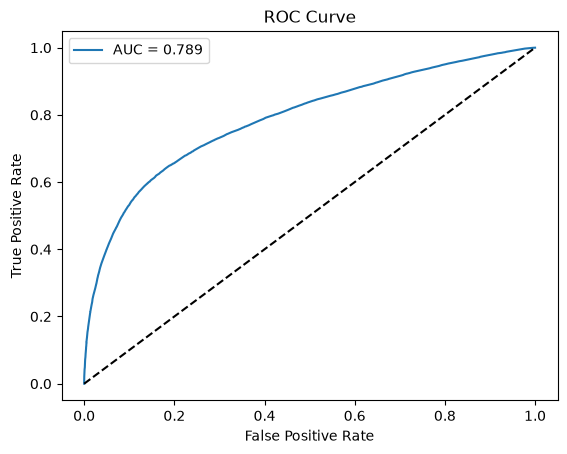

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = 0.789')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

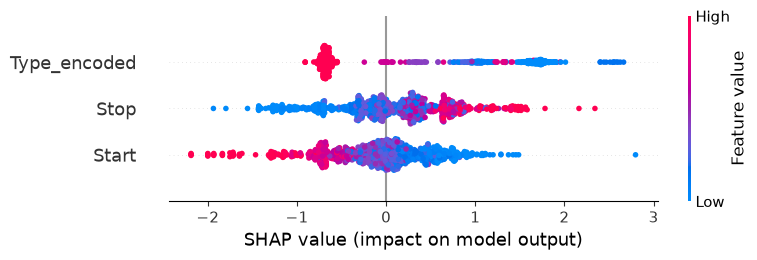

In [18]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test[:1000])
shap.summary_plot(shap_values, X_test[:1000])